In [1]:
import numpy as np
import librosa
import audioflux as af
import soundfile as sf
import matplotlib.pyplot as plt
import sklearn
import scipy
import writing
import analysis

Load the file and split into grains for analysis

non different:
flatness-centroid

c:\Users\hippo\miniconda3\envs\fieldmusic\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


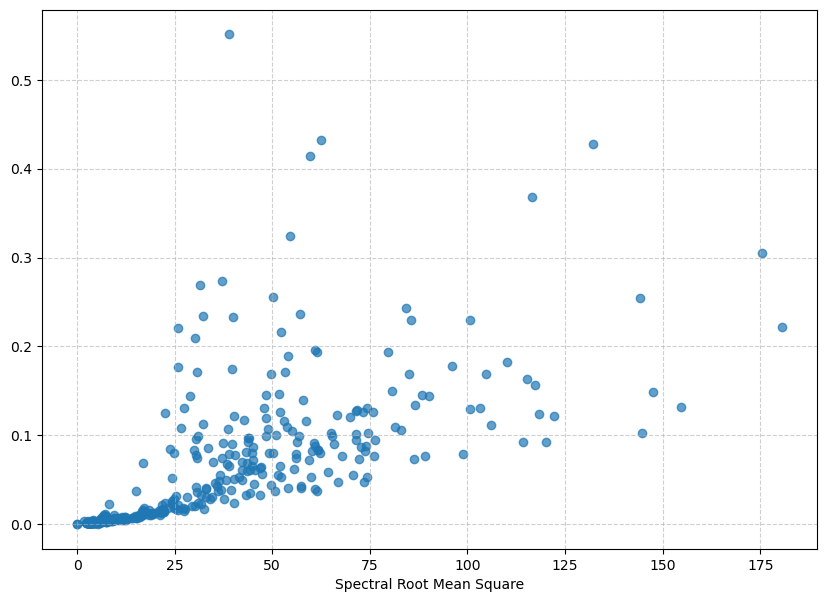

In [47]:
input_file = "..\..\corpus\\flute_sample_1\input.wav"
output_dir = "..\..\corpus\\flute_sample_1"

sr=48000
y, sr = af.read(input_file, samplate=sr) # sr is 48kHz

grain_duration = 0.1 # in s
grain_size = int(grain_duration * sr)
n_grains_in_source = int(len(y) // grain_size)
grains = [i*grain_size for i in range(n_grains_in_source)]

# since BFT is based on the FFT, the number of bins needs to be half that of a power of 2
bft_obj = af.BFT(num=2049, samplate=sr, radix2_exp=12, slide_length=grain_size,
               data_type=af.type.SpectralDataType.MAG,
               scale_type=af.type.SpectralFilterBankScaleType.LINEAR)
spec_arr = bft_obj.bft(y)
spec_arr = np.abs(spec_arr)
spectral_obj = af.Spectral(num=bft_obj.num,
                           fre_band_arr=bft_obj.get_fre_band_arr())
n_time = spec_arr.shape[-1]  
spectral_obj.set_time_length(n_time)
rms_arr = spectral_obj.rms(spec_arr)
centroid_arr = spectral_obj.kurtosis(spec_arr)

n_clusters=5
x = np.array([[i, j] for i, j in zip(rms_arr, centroid_arr)])
kmeans = sklearn.cluster.KMeans(n_clusters=n_clusters, n_init='auto', random_state=0).fit(x)
plt.figure(figsize=(10, 7))
plt.scatter(centroid_arr, rms_arr, alpha=0.7)
# plt.ylabel()
plt.xlabel("Spectral Root Mean Square")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

dict_clusters = {}
for idx, lab in enumerate(kmeans.labels_):
    dict_clusters[lab] = dict_clusters.get(lab, [])
    dict_clusters[lab].append(idx)


### Basic Concat Markov approach
- Using frequency sampling of grains for state transition matrix
- simple concat of grain to grain

In [3]:
frequency_matrix = np.zeros((n_clusters, n_clusters))
labels = kmeans.labels_
prev_label = labels[0]
for label_idx in range(1, len(labels)):
    frequency_matrix[prev_label][labels[label_idx]] += 1
    prev_label = labels[label_idx]
total_freq = np.sum(frequency_matrix)

probability_matrix = []#np.zeros((n_clusters, n_clusters))
for i in frequency_matrix:
    row = i / np.sum(i)
    probability_matrix.append(row)
transition_matrix_fin = np.array(probability_matrix)
transition_matrix_fin

array([[0.69660194, 0.29368932, 0.00970874],
       [0.05504587, 0.75433231, 0.19062181],
       [0.0393134 , 0.06644518, 0.89424142]])

This section of the notebook concerns actual synthesis

In [10]:
output_buffer = np.array([]) 
curr_label = 3
n_iterations = 100
seed = 100
s = np.random.seed(seed)

for i in range(n_iterations):

    next_label = np.random.choice(range(n_clusters), p=transition_matrix_fin[curr_label])
    grain_idx = np.random.choice(dict_clusters[next_label]) # uniform sampling from a cluster
    grain_y_idx = grains[grain_idx]
    grain = y[grain_y_idx:grain_y_idx+grain_size]
    grain = grain * np.hanning(grain_size)
    output_buffer = np.concatenate([output_buffer, grain])
    curr_label = next_label
# output_buffer / np.max(np.abs(output_buffer))
sf.write(f"..\..\corpus\piano_sample_1\output\mm_test_{n_iterations}_{grain_size}_{sr}_{curr_label}.wav", output_buffer, samplerate=sr)

Xenaxis matrix:
state 1: (c0,d0)
state 2: (c0,d1)
state 3: (c1,d1)
state 4: (c1,d2)
state 4: (c2,d2)
etc. ... 

Take n_clusters as possibilities for waveforms c0,c1,c2,...

Take densities as densities per $\Delta t$ d0,d1,d2,...

Values: 1, 3, 9/ $\Delta t$



In [41]:
n_densities = 3
n_states = n_densities * n_clusters
# np.random.seed(1)
randomized_matrix = np.random.rand(n_states,n_states)
mtp = []
for i in randomized_matrix:
    row = i / np.sum(i)
    mtp.append(row)
mtp = np.array(mtp)
mtp

array([[0.11202226, 0.13488218, 0.06266814, 0.04848369, 0.16091657,
        0.07689254, 0.17330187, 0.1191655 , 0.11166724],
       [0.02720627, 0.22512388, 0.10667416, 0.13713616, 0.09676923,
        0.05619909, 0.21419126, 0.13601939, 0.00068055],
       [0.11888259, 0.06292265, 0.10152888, 0.17066185, 0.06882201,
        0.17501402, 0.12007985, 0.0030477 , 0.17904046],
       [0.13280225, 0.19170257, 0.0331268 , 0.02635984, 0.17926085,
        0.13394041, 0.01268637, 0.14521296, 0.14490794],
       [0.26536749, 0.20456178, 0.03572762, 0.00571549, 0.0075356 ,
        0.00813805, 0.07078513, 0.24725611, 0.15491273],
       [0.11678001, 0.17787349, 0.0262308 , 0.05897572, 0.1237378 ,
        0.20482073, 0.11851395, 0.00393912, 0.16912839],
       [0.05954522, 0.20628569, 0.09913219, 0.22071018, 0.19095467,
        0.14216784, 0.0348762 , 0.01531419, 0.03101382],
       [0.01362289, 0.03286912, 0.06901649, 0.21801488, 0.17114799,
        0.00383932, 0.022008  , 0.29576984, 0.17371146],


In [25]:
state_dict = {}
densities = [1,3,9]
clusters = list(range(n_clusters))
states = []
for i in range(n_clusters):
    for j in range(n_densities):
        states.append([
            clusters[i], densities[j]
        ])
# for i in range(n_states):


### Markov chain approach 1
- basic init random state transition matrix for densities and grain cluster selection. 



In [ ]:
# TODO: 
output_buffer = np.array([]) 
n_iterations = 100
seed = 100
s = np.random.seed(seed)

delta_t = 1 # in seconds
delta_t_samples = int(delta_t * sr)
curr_state = 8

for _ in range(n_iterations):
    temp_buffer = np.zeros(delta_t_samples)

    next_state = np.random.choice(range(n_states), p=mtp[curr_state])
    print(next_state)
    cluster, density = states[next_state][0], states[next_state][1]

    grain_idx = np.random.choice(dict_clusters[cluster]) # uniform sampling from a cluster
    grain_y_idx = grains[grain_idx]
    grain = y[grain_y_idx:grain_y_idx+grain_size]
    grain = grain * np.hanning(grain_size)
    incr = int(temp_buffer.shape[-1] // density)
    for i in range(density):
        e = i*incr + len(grain)
        if e > temp_buffer.shape[-1]:
            e = temp_buffer.shape[-1]
        temp_buffer[i*incr:e] = temp_buffer[i*incr:e] + grain[:len(temp_buffer[i*incr:e])]
    temp_buffer = temp_buffer * np.hanning(temp_buffer.shape[-1])
    output_buffer = np.concatenate([output_buffer, temp_buffer])
    curr_state = next_state
# output_buffer / np.max(np.abs(output_buffer))
sf.write(f"..\..\corpus\piano_sample_1\output\mm_NEW_test_{n_iterations}_{grain_size}_{sr}_{delta_t}_{densities[-1]}_{n_clusters[-1]}.wav", output_buffer, samplerate=sr)

### Markov Screen Xenaxis approach
- separate state transition matrix for grain selection and grain parametre selection (density, size)
- currently using random initialization of state transition matrix 
- stereo effect on channels achieved using Haas effect (time shifting in ms timescale), coupled
to grain density parametre

In [77]:
# initial params setup
sr = 48000
seed = 2027
np.random.seed(seed)
densities = [0, 1, 4, 9, 49]#, 9, 16, 25, 36, 49]
sizes = [10, 40, 100, 200]
sizes = [size*sr//1000 for size in sizes]
stereo_shifting = [int(i*sr//1000/np.max(densities))*2 for i in densities]
# stereo_shifting = [i*sr//1000 for i in range(len(densities))]#[::-1] # low density is mono, high d is stereo (shifting by ms time)
n_poisson_states = len(densities) * len(sizes)
density_change_rate = 4
size_change_rate = 5

# states with possible density, size values
states = []
for i in range(len(sizes)):
    for j in range(len(densities)):
        states.append([
            sizes[i], densities[j]
        ])

# transition matrix for densities and grain sizes, currently rand init
# random
poisson_states_matrix_random = np.random.rand(n_poisson_states,n_poisson_states)
psm_random = []
for i in poisson_states_matrix_random:
    row = i / np.sum(i)
    psm_random.append(row)
psm_random = np.array(psm_random)

# poisson based multinomial PMF
""" 
Here the random variable, e.g. the param value of density, from one moment to the next is independent
of each other. We model its change (delta) to achieve the Markov assumption in a quasi-poisson approach. 
As we break the poisson constrains by only including specific states, specific inputs k to the 
poisson PMF for a given lambda (rate of change over delta_t) we move to a multinomial distr. This
multinomial distr models the probability of a random variable (density) entering a certain state, 
for one of K possible categories ([0,1,3,9,16] for instance). We use the partial poissons / total poissons 
to obtain normalized probabilities for each category. This way each row for a state in the state
transition matrix retains the needed properties, and, our change of states is dependent only on 
the prior state param values, thus on the prior state, as we use the change of values to compute
the quasi-poisson probabilities. The transitions of states will adhere to this quasi-poisson process
and result in, perhaps, an interesting output algorithmitcally. 
"""
def compute_partial_poisson(change_rate, k):
    """ 
    Here k is the change from state St to St+1 in some parametre
    and change_rate the change rate over the same time unit of t to t+1. 
    """
    nomin = (change_rate**k) * (np.exp(-change_rate)) 
    denomin = scipy.special.factorial(k)
    return nomin/denomin
density_transition_matrix = []
for idx, density in enumerate(densities):
    row = []
    for dens in densities:
        change = np.abs(density-dens)
        p = compute_partial_poisson(density_change_rate, change)
        row.append(p)
    row = np.array(row) / np.sum(row)
    density_transition_matrix.append(row)

grain_size_transition_matrix = []
for idx, size in enumerate(sizes[1:]):
    row = []
    for siz in sizes:
        change = np.abs(size-siz)
        p = compute_partial_poisson(size_change_rate, change)
        # print(p)
        # print(change)
    
        row.append(p)
    row = np.array(row) / np.sum(row)
    grain_size_transition_matrix.append(row)
rand_grain_size_m = np.random.rand(np.array(grain_size_transition_matrix).shape[0], np.array(grain_size_transition_matrix).shape[1])
rand_grain_size_m = np.array([[i for i in row] / np.sum(row) for row in rand_grain_size_m])

# pitch_shift_matrix = np.random.rand(len(pitch_shifting_steps), len(pitch_shifting_steps))
# pitch_shift_matrix = np.array([[i for i in row] / np.sum(row) for row in pitch_shift_matrix])


"""
The matrix for both densities and sizes is a product of probabilities, as these are simply independent events. 
Matrix of size x densities is of shape:
s0d0 s0d1 ... s0dn s1d0 ... s1dn ... sndn
...           
sndn  ...                        ... sndn
We can use a Kronecker Multiplicatoin here to get the product of the two matrices :) makes life easier 
"""
poisson_transition_matrix = np.kron(rand_grain_size_m, density_transition_matrix)
# poisson_transition_matrix = np.kron(poisson_transition_matrix, pitch_shift_matrix)

# cluster matrices for grain selection based on sampling
cluster_frequency_matrix = np.zeros((n_clusters, n_clusters))
labels = kmeans.labels_
prev_label = labels[0]
for label_idx in range(1, len(labels)):
    cluster_frequency_matrix[prev_label][labels[label_idx]] += 1
    prev_label = labels[label_idx]
probability_matrix = []
for i in cluster_frequency_matrix:
    row = i / np.sum(i)
    probability_matrix.append(row)
transition_matrix_fin = np.array(probability_matrix)

In [82]:
# TODO: 
output_buffer = np.array([[],[]]) 
n_iterations = 100*4
np.random.seed(seed)

multiplier = 1
def get_delta_t(multiplier):
    """
    Temp function to test change the number of samples per screen based on some
    2^n exponent (n). 

    """

    bpm = 120 * 1 << multiplier
    bps = bpm/60
    beat_duration = 1 / bps
    delta_t = beat_duration
    # print(delta_t)
    # delta_t = 0.2 # in seconds
    delta_t_samples = int(delta_t * sr)
    return delta_t_samples


bpm = 121*1 << multiplier
bps = bpm/60
beat_duration = 1 / bps
delta_t = beat_duration
print(delta_t)
# delta_t = 0.2 # in seconds
delta_t_samples = int(delta_t * sr)



max_grains = 2 # constant

init_cluster_states = [int(np.random.choice(range(n_clusters))) for _ in range(max_grains)]
init_poisson_states = [int(np.random.choice(range(len(poisson_transition_matrix)))) for _ in range(max_grains)]
curr_cluster_states = init_cluster_states
curr_poisson_states = init_poisson_states
# print(curr_cluster_states)
window = np.hanning

num_chans = 2
grain_lengths = []
for _ in range(n_iterations):
    temp_buffer = np.zeros((num_chans, delta_t_samples)) # two output channels
    multiplier = np.random.choice(range(1,7))
    delta_t_samples = get_delta_t(multiplier)
    for i in range(max_grains):
        # get the cluster state and change the state tracking array
        next_cluster_state = np.random.choice(range(n_clusters), p=transition_matrix_fin[curr_cluster_states[i]])
        curr_cluster_states[i] = next_cluster_state

        grain_idx = np.random.choice(dict_clusters[next_cluster_state]) 
        try:
            grain_y_idx = grains[grain_idx] # grain index in the original audio array input.wav 
        except Exception as e:
            grain_idx -= 1
            grain_y_idx = grains[grain_idx]

        # get the density and grain size
        next_poisson_state = np.random.choice(range(n_poisson_states), p=poisson_transition_matrix[curr_poisson_states[i]])
        grain_size, density = states[next_poisson_state][0], states[next_poisson_state][1]
        grain_y_end = grain_y_idx + grain_size
        if grain_y_end > y.shape[-1]:
            grain_y_end = y.shape[-1] # clipping if exceeds input audio bounds
        grain = y[grain_y_idx:grain_y_end]
        
        # TODO: apply pitch shift?     

        if window:
            grain = grain * window(len(grain))
    
        # get the stereo shift
        stereo_shift = stereo_shifting[densities.index(density)]
        # print(f"grain length: {len(grain)}")
        # print(density)
        grain_lengths.append(len(grain))
        # skip this iteration if no grain
        if density == 0:
            continue

        # apply the density
        incr = int(temp_buffer.shape[-1] // density)
        # print("INCr:" , incr)
        for i in range(density):
            e = i*incr + len(grain)
            if e > temp_buffer.shape[-1]:
                e = temp_buffer.shape[-1]
            for j in range(num_chans):
                temp_buffer[j][i*incr:e] = temp_buffer[j][i*incr:e] + grain[:len(temp_buffer[j][i*incr:e])]
        # apply stereo shift
        if stereo_shift:
            temp_buffer[-1] = np.concatenate([np.zeros(stereo_shift), temp_buffer[-1][:-stereo_shift]])

        # apply windowing 
        if window:
            for k in range(num_chans):
                temp_buffer[k] = temp_buffer[k] * window(temp_buffer.shape[-1])

        output_buffer = np.concatenate([output_buffer, temp_buffer], axis=1)

# output_buffer / np.max(np.abs(output_buffer))



0.24793388429752067


In [83]:
try:
    window_name = window.__name__
except AttributeError as e:
    window_name = "None"
parametre_dict = {
    "random_seed" : seed,
    "sample_rate" : sr,
    "input_file" : input_file, 
    "n_clusters" : n_clusters,
    "densities" : densities,
    "grain_sizes" : sizes,
    "n_iterations" : n_iterations,
    "stereo_shifts" : stereo_shifting,
    "delta_t" : delta_t,
    "max_grains" : max_grains,
    "num_chans" : num_chans,
    "init_states_densities_sizes" : [int(i) for i in init_poisson_states],
    "init_states_grain_cluster" : [int(i) for i in init_cluster_states],
    # "git_hash" : TODO: add git hash,
    "project" : "markov_gs",
    "poisson_change_rates" : int(density_change_rate),
    "window" : window_name
}
# str = json.dumps(parametre_dict, sort_keys=True)
for k,v in parametre_dict.items():
    print(type(v))
writing.save_output_data(output_buffer.T, sr, parametre_dict, output_dir)

<class 'int'>
<class 'int'>
<class 'str'>
<class 'int'>
<class 'list'>
<class 'list'>
<class 'int'>
<class 'list'>
<class 'float'>
<class 'int'>
<class 'int'>
<class 'list'>
<class 'list'>
<class 'str'>
<class 'int'>
<class 'str'>


In [63]:
y, sr = af.read(input_file, samplate=sr)
sf.write(file="..\\..\\audio_demo\\input_clipped.wav",data=y[sr*10:-300*sr], samplerate=sr)

### Same Algorithm, now with different input

In [2]:
import numpy as np
import librosa
import audioflux as af
import soundfile as sf
import matplotlib.pyplot as plt
import sklearn
import scipy
import writing
import analysis

In [5]:
dir = "..\..\corpus\metro_sample_2"
sr = 48000
grain_duration = 0.1
sound_obj = analysis.AnalysisObject(dir,sr)
sound_obj.input

'\\input.wav'